In [16]:
import numpy as np
from PIL import Image, ImageDraw
import cv2
from typing import Tuple, Dict, Optional
from pathlib import Path
import random
import matplotlib.pyplot as plt

In [17]:
X_LEFT = 980
X_MID_LEFT = 1250
X_MID_RIGHT = 2700
X_RIGHT = 3100
 
Y_TOP_LEFT = 500
Y_TOP = 850
Y_BOTTOM = 1900
Y_BOTTOM_RIGHT = 2200

In [18]:
def is_image_noisy(img: np.ndarray) -> bool:
    """
    Determine if the image has a noisy background or white background.
 
    Args:
        img: The input image as numpy array
 
    Returns:
        True if the image is noisy, False if the image has white background
    """
    return bool(img.std() > 45)

In [19]:
def get_sector_polygons(img: Image.Image) -> Dict[str, list]:
    """
    Get polygon coordinates for each of the 5 sectors (4 players + center).
 
    Args:
        img: PIL Image object
 
    Returns:
        Dictionary mapping sector names to polygon coordinates
    """
    width, height = img.size
 
    polygons = {
        "p3": [
            (0, 0),
            (X_RIGHT, 0),
            (X_RIGHT, Y_TOP),
            (X_LEFT, Y_TOP),
            (X_LEFT, Y_TOP_LEFT),
            (0, Y_TOP_LEFT)
        ],
 
        "p4": [
            (0, Y_TOP_LEFT),
            (X_LEFT, Y_TOP_LEFT),
            (X_LEFT, Y_TOP),
            (X_MID_LEFT, Y_TOP),
            (X_MID_LEFT, Y_BOTTOM),
            (X_LEFT, Y_BOTTOM),
            (X_LEFT, height),
            (0, height)
        ],
 
        "Center": [
            (X_MID_LEFT, Y_TOP),
            (X_MID_RIGHT, Y_TOP),
            (X_MID_RIGHT, Y_BOTTOM),
            (X_MID_LEFT, Y_BOTTOM)
        ],
 
        "p2": [
            (X_RIGHT, 0),
            (width, 0),
            (width, Y_BOTTOM_RIGHT),
            (X_RIGHT, Y_BOTTOM_RIGHT),
            (X_RIGHT, Y_BOTTOM),
            (X_MID_RIGHT, Y_BOTTOM),
            (X_MID_RIGHT, Y_TOP),
            (X_RIGHT, Y_TOP)
        ],
 
        "p1": [
            (X_LEFT, Y_BOTTOM),
            (X_RIGHT, Y_BOTTOM),
            (X_RIGHT, Y_BOTTOM_RIGHT),
            (width, Y_BOTTOM_RIGHT),
            (width, height),
            (X_LEFT, height)
        ]
    }
 
    return polygons

In [20]:
def extract_sector(img: Image.Image, polygon: list) -> Tuple[Image.Image, Image.Image]:
    """
    Extract a sector from the image based on polygon coordinates.
 
    Args:
        img: PIL Image object
        polygon: List of (x, y) coordinates defining the sector
 
    Returns:
        Tuple of (sector_image, mask_image)
    """
    width, height = img.size
 
    # Create mask
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon(polygon, fill=255)
 
    bbox = mask.getbbox()
 
    # Extract sector
    sector = Image.new("RGB", (width, height), "white")
    sector.paste(img, mask=mask)
 
    sector_crop = sector.crop(bbox)
    mask_crop = mask.crop(bbox)
 
    return sector_crop, mask_crop

In [22]:
def detect_yellow_circular_marker_hough(
    sector_img: Image.Image, 
    mask: Image.Image,
    hue_range=(22, 28),
    sat_min=100,
    val_min=100,
    dp=1.5,
    min_dist=50,
    param1=50,
    param2=30,
    min_radius=60,
    max_radius=100,
    yellow_threshold=0.7,      # Minimum fraction that must be yellow
    saturation_threshold=0.2,  # NEW: Minimum average saturation (filters out white)
    debug=True
) -> bool:
    """
    Detect yellow circular marker using Hough Circle Transform
    """
    img_np = np.array(sector_img)
    mask_np = np.array(mask)
    
    # Convert to HSV and detect yellow
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    lower_yellow = np.array([hue_range[0], sat_min, val_min])
    upper_yellow = np.array([hue_range[1], 255, 255])
    yellow_mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Apply sector mask
    masked_yellow = cv2.bitwise_and(yellow_mask, yellow_mask, mask=mask_np)
    
    # Optional: light cleanup
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(masked_yellow, cv2.MORPH_OPEN, kernel)
    
    if debug:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 4, 1)
        plt.title("Original")
        plt.imshow(img_np)
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.title("Yellow Mask")
        plt.imshow(masked_yellow, cmap='gray')
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.title("Cleaned")
        plt.imshow(cleaned, cmap='gray')
        plt.axis('off')
    
    # Apply Hough Circle Transform
    circles = cv2.HoughCircles(
        cleaned,
        cv2.HOUGH_GRADIENT,
        dp=dp,
        minDist=min_dist,
        param1=param1,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )
    
    # Filter circles by yellow content AND saturation
    valid_circles = []
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            center = (i[0], i[1])
            radius = i[2]
            
            # Create a circular mask for this circle
            circle_mask = np.zeros_like(cleaned)
            cv2.circle(circle_mask, center, radius, 255, -1)
            
            # Count yellow pixels within the circle (from cleaned mask)
            yellow_in_circle = cv2.bitwise_and(cleaned, circle_mask)
            yellow_pixel_count = np.sum(yellow_in_circle > 0)
            total_circle_pixels = np.sum(circle_mask > 0)
            yellow_ratio = yellow_pixel_count / total_circle_pixels if total_circle_pixels > 0 else 0
            
            # NEW: Check average saturation in the original HSV image
            # This filters out white regions (which have low saturation)
            circle_mask_3d = np.stack([circle_mask] * 3, axis=-1) > 0
            saturation_channel = hsv[:, :, 1]  # S channel
            circle_saturations = saturation_channel[circle_mask > 0]
            avg_saturation = np.mean(circle_saturations) / 255.0 if len(circle_saturations) > 0 else 0
            
            if debug:
                print(f"Circle at ({i[0]}, {i[1]}), r={i[2]}:")
                print(f"  Yellow ratio: {yellow_ratio:.2%}")
                print(f"  Avg saturation: {avg_saturation:.2%}")
            
            # Filter: must have enough yellow AND enough saturation
            if yellow_ratio >= yellow_threshold and avg_saturation >= saturation_threshold:
                valid_circles.append(i)
                if debug:
                    print(f"  ✅ VALID")
            else:
                if debug:
                    reasons = []
                    if yellow_ratio < yellow_threshold:
                        reasons.append(f"yellow {yellow_ratio:.2%} < {yellow_threshold:.2%}")
                    if avg_saturation < saturation_threshold:
                        reasons.append(f"saturation {avg_saturation:.2%} < {saturation_threshold:.2%}")
                    print(f"  ❌ REJECTED ({', '.join(reasons)})")
    
    # Visualize detected circles
    if debug:
        vis_img = img_np.copy()
        if circles is not None:
            for i in circles[0, :]:
                center = (i[0], i[1])
                radius = i[2]
                is_valid = any(np.array_equal(i, v) for v in valid_circles)
                color = (0, 255, 0) if is_valid else (255, 0, 0)
                thickness = 3 if is_valid else 2
                
                cv2.circle(vis_img, center, radius, color, thickness)
                cv2.circle(vis_img, center, 2, color, 3)
        
        plt.subplot(1, 4, 4)
        plt.title(f"Valid: {len(valid_circles)}/{len(circles[0]) if circles is not None else 0}")
        plt.imshow(vis_img)
        plt.axis('off')
        plt.show()
    
    if len(valid_circles) > 0:
        if debug:
            print(f"✅ Detected {len(valid_circles)} valid yellow circle(s)")
        return True
    
    if debug:
        print("❌ No valid yellow circles detected")
    return False

In [40]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def detect_black_rectangular_marker_debug(
    sector_img: Image.Image,
    mask: Image.Image,
    debug=True
) -> bool:
    """
    Debug version with visualization at every step
    for detecting black rectangular markers.
    """

    # Convert to numpy arrays
    img_np = np.array(sector_img)
    mask_np = np.array(mask)
    
    # ---------------------------------------------------
    # Step 1: Show original image and mask
    # ---------------------------------------------------
    if debug:
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("Original Image")
        plt.imshow(img_np)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Sector Mask")
        plt.imshow(mask_np, cmap='gray')
        plt.axis('off')

    # ---------------------------------------------------
    # Step 2: Convert to grayscale
    # ---------------------------------------------------
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    if debug:
        plt.subplot(1, 3, 3)
        plt.title("Grayscale")
        plt.imshow(gray, cmap='gray')
        plt.axis('off')

        plt.show()

    # ---------------------------------------------------
    # Step 3: Threshold for black regions
    # ---------------------------------------------------
    threshold_value = 150

    _, black_mask = cv2.threshold(
        gray,
        threshold_value,
        255,
        cv2.THRESH_BINARY_INV
    )
    if debug:
        print(
            "Gray min:", gray.min(),
            "Gray max:", gray.max(),
            "Gray mean:", gray.mean()
        )

    if debug:
        plt.figure(figsize=(6,6))
        plt.imshow(gray, cmap='gray')
        plt.colorbar()
        plt.title("Gray Intensities")
        plt.show()

    if debug:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.title(f"Raw Black Mask\nThreshold={threshold_value}")
        plt.imshow(black_mask, cmap='gray')
        plt.axis('off')

    # ---------------------------------------------------
    # Step 4: Apply sector mask
    # ---------------------------------------------------
    masked_black = cv2.bitwise_and(
        black_mask,
        black_mask,
        mask=mask_np
    )

    if debug:
        plt.subplot(1, 2, 2)
        plt.title("Masked Black Regions")
        plt.imshow(masked_black, cmap='gray')
        plt.axis('off')

        plt.show()

    # ---------------------------------------------------
    # Step 5: Morphological cleanup
    # ---------------------------------------------------
    kernel = np.ones((11, 11), np.uint8)

    cleaned = cv2.morphologyEx(
        masked_black,
        cv2.MORPH_OPEN,
        kernel
    )

    cleaned = cv2.morphologyEx(
        cleaned,
        cv2.MORPH_CLOSE,
        kernel
    )

    if debug:
        plt.figure(figsize=(5, 5))
        plt.title("Cleaned Mask")
        plt.imshow(cleaned, cmap='gray')
        plt.axis('off')
        plt.show()

    # ---------------------------------------------------
    # Step 6: Find contours
    # ---------------------------------------------------
    contours, _ = cv2.findContours(
        cleaned,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # ---------------------------------------------------
    # Step 7: Visualize contours
    # ---------------------------------------------------
    contour_vis = img_np.copy()

    cv2.drawContours(
        contour_vis,
        contours,
        -1,
        (255, 0, 0),
        2
    )

    if debug:
        plt.figure(figsize=(6, 6))
        plt.title(f"Contours Found: {len(contours)}")
        plt.imshow(contour_vis)
        plt.axis('off')
        plt.show()

    # ---------------------------------------------------
    # Step 8: Analyze contours
    # ---------------------------------------------------
    for i, contour in enumerate(contours):

        area = cv2.contourArea(contour)

        if debug:
            print(f"\nContour {i}")
            print(f"Area: {area:.2f}")

        # Ignore tiny contours
        if area < 35000:
            if debug:
                print("Rejected: area too small")
            continue

        # Approximate polygon
        epsilon = 0.02 * cv2.arcLength(contour, True)

        approx = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        num_vertices = len(approx)

        # Bounding box
        x, y, w, h = cv2.boundingRect(contour)

        aspect_ratio = float(w) / h if h > 0 else 0

        if debug:
            print(f"Vertices: {num_vertices}")
            print(f"Bounding Box: x={x}, y={y}, w={w}, h={h}")
            print(f"Aspect Ratio: {aspect_ratio:.2f}")

        # Draw bounding box visualization
        debug_vis = img_np.copy()

        cv2.drawContours(debug_vis, [contour], -1, (0, 255, 0), 2)

        cv2.rectangle(
            debug_vis,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        if debug:
            plt.figure(figsize=(5, 5))
            plt.title(
                f"Contour {i}\n"
                f"Area={area:.0f}, "
                f"Vertices={num_vertices}, "
                f"AR={aspect_ratio:.2f}"
            )
            plt.imshow(debug_vis)
            plt.axis('off')
            plt.show()

        # Rectangle-like contour check
        if 4 <= num_vertices <= 8:

            # Aspect ratio filter
            if 0.55 < aspect_ratio < 1.65:

                if debug:
                    print("✅ Black rectangular marker detected")

                return True

            else:
                if debug:
                    print("Rejected: bad aspect ratio")

        else:
            if debug:
                print("Rejected: not rectangle-like")

    if debug:
        print("\n❌ No black rectangular marker detected")

    return False

In [42]:
def detect_active_player(img_input) -> Dict[str, any]:
    """
    Main function to detect the active player in an UNO game image.
    
    Pipeline:
    1. Takes the image
    2. Classifies as noisy or white background
    3. Segments into five areas (4 players + center)
    4. Detects markers based on image type:
       - Yellow circular marker for noisy images
       - Black rectangular marker for white background images
    5. Returns the active player sector
    
    Args:
        img_input: Can be:
            - numpy array (H, W, 3)
            - PIL Image
            - str (file path)
    
    Returns:
        Dictionary containing:
            - 'active_player': Name of the active player sector (e.g., "Player 1")
            - 'is_noisy': Boolean indicating if image is noisy
            - 'marker_type': "yellow_circle" or "black_rectangle"
            - 'sectors': Dictionary of all segmented sectors
            - 'detections': Dictionary showing which sectors had markers
    """
    
    # 1. Load and normalize input
    if isinstance(img_input, str):
        img_pil = Image.open(img_input).convert("RGB")
        img_np = np.array(img_pil)
    elif isinstance(img_input, np.ndarray):
        img_np = img_input
        img_pil = Image.fromarray(img_np.astype('uint8'))
    elif isinstance(img_input, Image.Image):
        img_pil = img_input.convert("RGB")
        img_np = np.array(img_pil)
    else:
        raise ValueError("Input must be numpy array, PIL Image, or file path")
    
    # 2. Classify image as noisy or white background
    is_noisy = is_image_noisy(img_np)
    marker_type = "yellow_circle" if is_noisy else "black_rectangle"
    
    # 3. Segment into five areas
    polygons = get_sector_polygons(img_pil)
    sectors = {}
    masks = {}
    
    for sector_name, polygon in polygons.items():
        sector_img, mask_img = extract_sector(img_pil, polygon)
        sectors[sector_name] = sector_img
        masks[sector_name] = mask_img
    
    # 4. Detect markers in each sector (skip Center)
    detections = {}
    active_player = None
    
    for sector_name in ["p1", "p2", "p3", "p4"]:
        sector_img = sectors[sector_name]
        mask_img = masks[sector_name]
        
        if is_noisy:
            # Look for yellow circular marker
            has_marker = detect_yellow_circular_marker_hough(sector_img, mask_img, debug=False)
        else:
            # Look for black rectangular marker
            has_marker = detect_black_rectangular_marker_debug(sector_img, mask_img, debug=False)
            #return False
        
        detections[sector_name] = has_marker
        
        # 5. Identify active player
        if has_marker and active_player is None:
            active_player = sector_name
    
    # Return comprehensive results
    return {
        'active_player': active_player,
        'is_noisy': is_noisy,
        'marker_type': marker_type,
        'sectors': sectors,
        'detections': detections,
        'all_detections': detections  # For debugging
    }

In [27]:
def visualize_detection_result(result: Dict, save_path: Optional[str] = None):
    """
    Visualize the detection result with all sectors and highlight the active player.
    
    Args:
        result: Output dictionary from detect_active_player()
        save_path: Optional path to save the visualization
    """
    import matplotlib.pyplot as plt
    
    sectors = result['sectors']
    active_player = result['active_player']
    detections = result['detections']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    sector_names = ["p1", "p2", "p3", "p4", "Center"]
    
    for i, sector_name in enumerate(sector_names):
        axes[i].imshow(sectors[sector_name])
        
        title = sector_name
        if sector_name in detections:
            title += f" - Marker: {'✓' if detections[sector_name] else '✗'}"
        if sector_name == active_player:
            title = f">>> {title} (ACTIVE) <<<"
            axes[i].set_facecolor('gold')
            for spine in axes[i].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(4)
        
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].axis('off')
    
    # Info panel
    axes[5].axis('off')
    info_text = f"""
    DETECTION RESULTS
    ═════════════════
    
    Active Player: {active_player if active_player else 'None detected'}
    
    Image Type: {'Noisy Background' if result['is_noisy'] else 'White Background'}
    
    Marker Type: {result['marker_type']}
    
    Detections:
    {chr(10).join([f'  {name}: {"✓ Found" if found else "✗ Not found"}' 
                   for name, found in detections.items()])}
    """
    axes[5].text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                verticalalignment='center')
    
    plt.suptitle(f'Active Player Detection - {active_player if active_player else "No marker detected"}',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

In [43]:
import pandas as pd
from pathlib import Path
from PIL import Image

csv_path = r"C:\Users\Vidhi\ee-451-final\data\train.csv"
df = pd.read_csv(csv_path)

# Example: make sure you have a column that matches image filenames
# e.g. df['image'] and df['active_player']

# Create a dictionary: filename -> label
label_map = dict(zip(df['image_id'] + '.jpg', df['active_player']))


print(label_map)

{'L1000770.jpg': 'p3', 'L1000771.jpg': 'p1', 'L1000772.jpg': 'p2', 'L1000773.jpg': 'p4', 'L1000774.jpg': 'p3', 'L1000775.jpg': 'p4', 'L1000776.jpg': 'p2', 'L1000777.jpg': 'p2', 'L1000778.jpg': 'p4', 'L1000779.jpg': 'p1', 'L1000780.jpg': 'p4', 'L1000781.jpg': 'p1', 'L1000782.jpg': 'p4', 'L1000783.jpg': 'p1', 'L1000784.jpg': 'p2', 'L1000785.jpg': 'p4', 'L1000786.jpg': 'p4', 'L1000787.jpg': 'p2', 'L1000788.jpg': 'p3', 'L1000789.jpg': 'p4', 'L1000790.jpg': 'p1', 'L1000791.jpg': 'p1', 'L1000836.jpg': 'p3', 'L1000837.jpg': 'p1', 'L1000838.jpg': 'p3', 'L1000839.jpg': 'p4', 'L1000840.jpg': 'p1', 'L1000841.jpg': 'p1', 'L1000842.jpg': 'p2', 'L1000843.jpg': 'p2', 'L1000844.jpg': 'p2', 'L1000846.jpg': 'p3', 'L1000847.jpg': 'p1', 'L1000848.jpg': 'p4', 'L1000849.jpg': 'p4', 'L1000850.jpg': 'p1', 'L1000851.jpg': 'p1', 'L1000852.jpg': 'p1', 'L1000853.jpg': 'p1', 'L1000855.jpg': 'p2', 'L1000856.jpg': 'p2', 'L1000857.jpg': 'p3', 'L1000902.jpg': 'p2', 'L1000903.jpg': 'p1', 'L1000904.jpg': 'p1', 'L1000905

In [44]:
img_dir = Path(r"C:\Users\Vidhi\ee-451-final\data\train_images")
image_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))

print(f"Total of images: {len(image_paths)}")

sample_paths = random.sample(image_paths, 5)
"""
for path in sample_paths:
    print(path)
    img = Image.open(path)
    result = detect_active_player(img)
    print(f"Active player: {result['active_player']}")
    visualize_detection_result(result)
"""

Total of images: 81


'\nfor path in sample_paths:\n    print(path)\n    img = Image.open(path)\n    result = detect_active_player(img)\n    print(f"Active player: {result[\'active_player\']}")\n    visualize_detection_result(result)\n'

Active player: p1


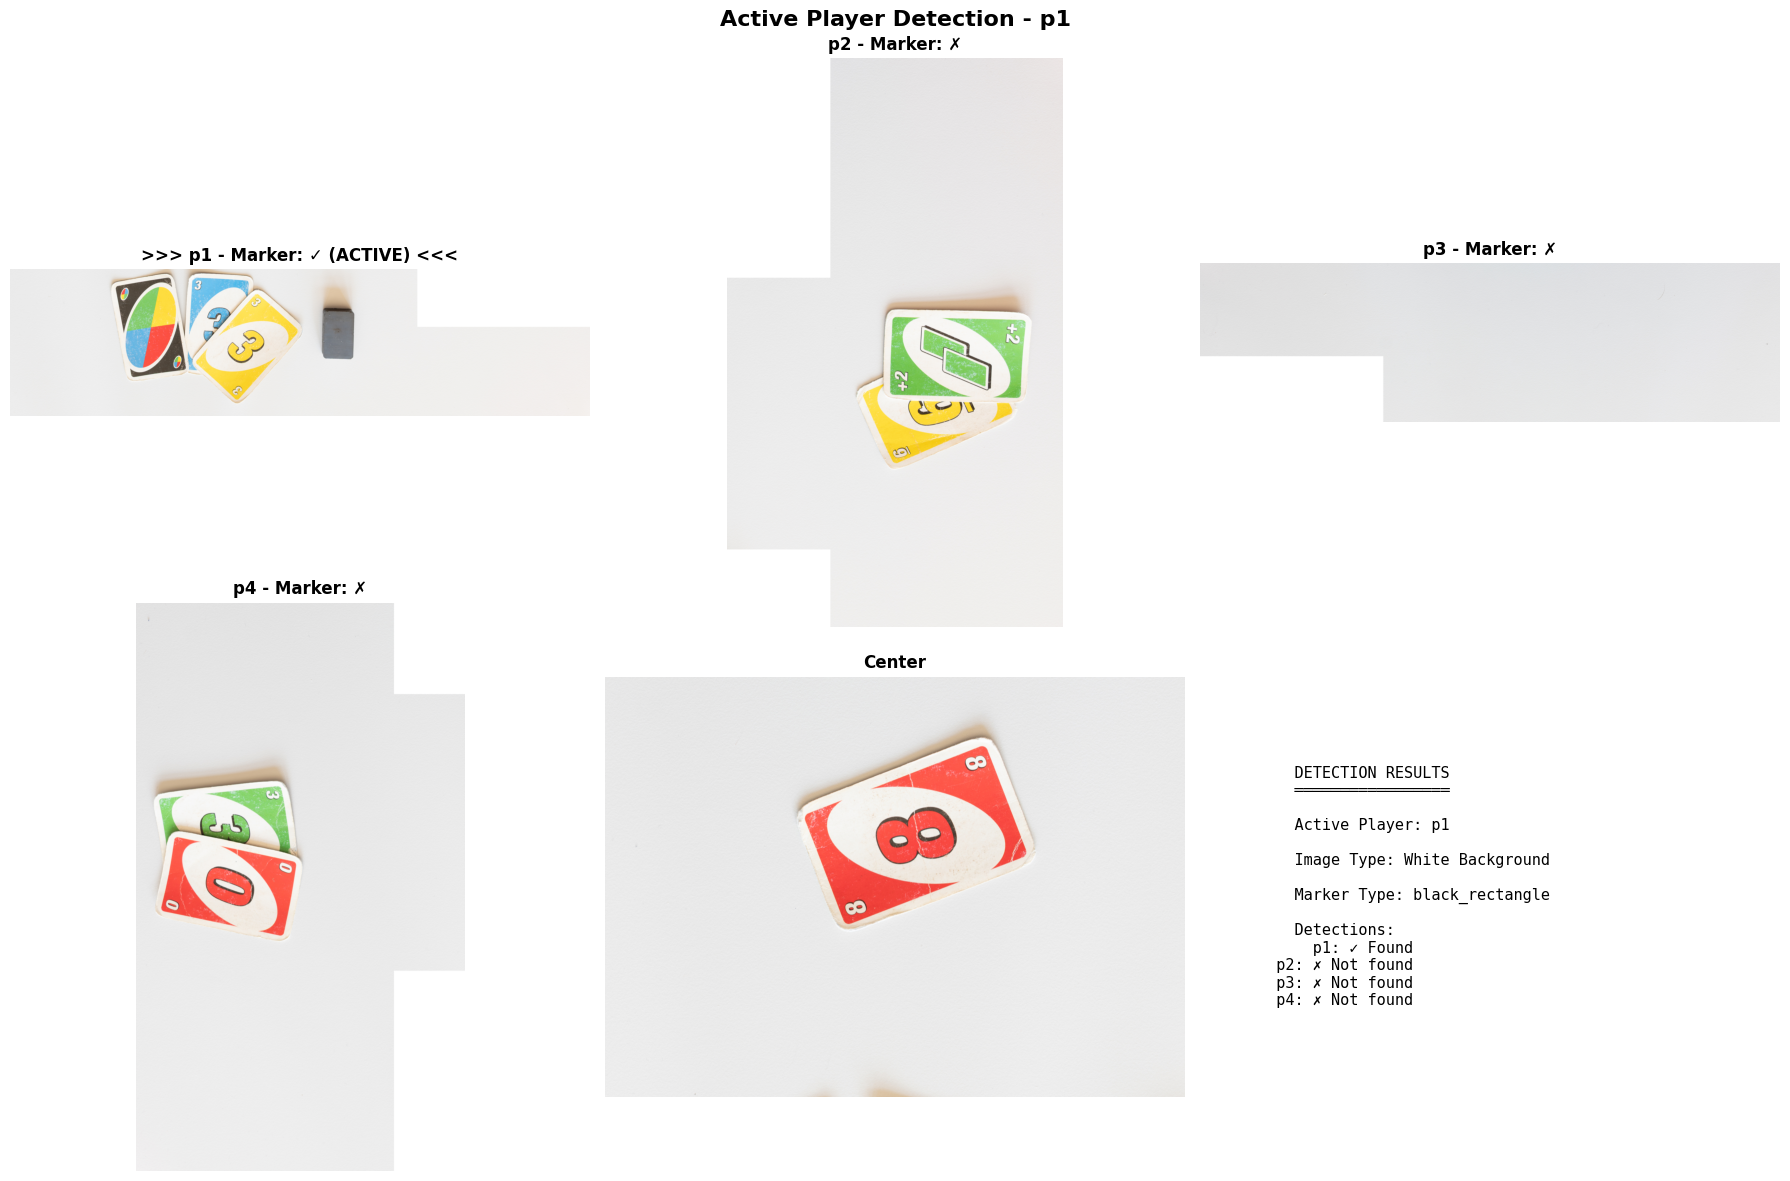

p1


In [ ]:
img = Image.open(r"C:\Users\Vidhi\ee-451-final\data\test_images\L1000860.jpg")
result = detect_active_player(img)
print(f"Active player: {result['active_player']}")
visualize_detection_result(result)

print(result['active_player'])

In [ ]:
img_dir = Path(r"C:\Users\Vidhi\ee-451-final\data\train_images")

image_paths = list(img_dir.glob("*.jpg")) + \
              list(img_dir.glob("*.png")) + \
              list(img_dir.glob("*.jpeg"))

correct = 0
total = 0

for img_path in image_paths:
    filename = img_path.name
    
    if filename not in label_map:
        continue  # skip if no label exists
    
    img = Image.open(img_path)
    result = detect_active_player(img)
    
    pred = result['active_player']
    true = label_map[filename]
    
    if pred == true:
        correct += 1
    else:
        print(img_path)
    total += 1

accuracy = correct / total if total > 0 else 0
print(f"Accuracy: {accuracy:.4f} ({correct}/{total})")

Accuracy: 1.0000 (81/81)


In [ ]:
img_dir = Path(r"C:\Users\Vidhi\ee-451-final\data\train_images")
image_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))

print(f"Total of images: {len(image_paths)}")

sample_paths = random.sample(image_paths, 2)

Total of images: 81
